# SMF 00 · Stellar-mass completeness limit from the spectroscopic limit

Derives the stellar-mass completeness limit M_lim of the spectroscopic member sample: the 90th-percentile M* in bins of M_r is fitted with a line, and M_lim is the value of that line at the absolute magnitude corresponding to the spectroscopic completeness limit (`MACH_1dspec_limit.csv`). Done once for the stacked sample (fixed M_r = −17.337) and once per cluster.

**Inputs** (not included): `DATA/MACH_MASS/MACH_DR18_3R200_mastercat.csv` (with CIGALE stellar masses), `DATA/MACH_PHOT/AllHeCS_VAC_updated.csv`, `MACH_1dspec_limit.csv`

**Output**: none (limits are printed; the per-cluster table can be saved by uncommenting the last lines)

In [1]:
# ============================================================================
# Setup
# ============================================================================
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator
from astropy.cosmology import LambdaCDM

# Cosmology used throughout this project
cosmo = LambdaCDM(H0=70, Om0=0.3, Ode0=0.7)

# Matplotlib style shared by the notebooks of this repository
plt.rcParams.update({
    "font.family": 'STIXGeneral',
    'text.usetex': False,
    "mathtext.fontset": 'cm',
    "axes.labelweight": "normal",
    'font.size': 25,
    'font.weight': 'normal',
    'xtick.direction': 'in',
    'ytick.direction': 'in',
    'xtick.top': True,
    'ytick.right': True,
    'xtick.minor.visible': True,
    'ytick.minor.visible': True,
    'xtick.major.size': 10,
    'xtick.minor.size': 6,
    'ytick.major.size': 10,
    'ytick.minor.size': 6,
    'xtick.major.width': 1.6,
    'xtick.minor.width': 1.6,
    'ytick.major.width': 1.6,
    'ytick.minor.width': 1.6,
    'lines.linewidth': 2,
    'axes.linewidth': 4,
    'axes.labelpad': 4,
    'xtick.major.pad': 7,
    'image.origin': 'lower'
})

# Show every column when a DataFrame is displayed
pd.set_option('display.max_columns', None)

# The nine MACH clusters
MACHLIST = ['A2245', 'A1767', 'A2244', 'A1831', 'A2034', 'A7', 'A2255', 'A2029', 'A2065']

# Repository root, located relative to this notebook; DATA/ and FIGURE/ hang off it
MAINPATH = os.path.abspath(os.path.join(os.getcwd(), '..', '..', '..'))
FIGUREPATH = f"{MAINPATH}/FIGURE/IMAGES"

%config InlineBackend.figure_format = 'retina'

In [2]:
# Load MACH master catalog
mach_path = f"{MAINPATH}/DATA/MACH_MASS/MACH_DR18_3R200_mastercat.csv"
mach_data = pd.read_csv(mach_path)

# Correct cmodel magnitudes for extinction
for band in ("g", "r"):
    mach_data[f"cmodelMag_{band}_0"] = (
        mach_data[f"cmodelMag_{band}"] - mach_data[f"extinction_{band}"]
    )

# Load HeCS VAC catalog
hecs_vac_path = f"{MAINPATH}/DATA/MACH_PHOT/AllHeCS_VAC_updated.csv"
hecs_vac_data = pd.read_csv(hecs_vac_path)

# Galaxies within 1 R200
df = mach_data.loc[mach_data["Rcl/R200"] <= 1.0].copy()

# Compute absolute r-band magnitude
lum_dist_pc = cosmo.luminosity_distance(df["Z_TOT_Z"]).to("pc").value
df["AbsMag_r"] = df["cmodelMag_r_0"] - 5 * np.log10(lum_dist_pc / 10)
df = df.loc[df["AbsMag_r"].notna()].copy()

# Spectroscopic members only
df_mach_members = df.loc[df["MEMBER"] == "Y"].copy()

# Spectroscopic completeness limits per cluster
exceed_bin_df = pd.read_csv("MACH_1dspec_limit.csv")

/Users/jonginpark/anaconda3/envs/work1/lib/python3.12/site-packages/astropy/cosmology/flrw/lambdacdm.py:397: RuntimeWarning: invalid value encountered in sqrt
  return 2 * np.sqrt(x) * hyp2f1(1.0 / 6, 1.0 / 2, 7.0 / 6, -(x**3))
/var/folders/8j/r5cxq2xj3bxdkw71t64p365m0000gn/T/ipykernel_58488/106175471.py:20: RuntimeWarning: divide by zero encountered in log10
  df["AbsMag_r"] = df["cmodelMag_r_0"] - 5 * np.log10(lum_dist_pc / 10)
/var/folders/8j/r5cxq2xj3bxdkw71t64p365m0000gn/T/ipykernel_58488/106175471.py:20: RuntimeWarning: invalid value encountered in log10
  df["AbsMag_r"] = df["cmodelMag_r_0"] - 5 * np.log10(lum_dist_pc / 10)


STACKED sample intersection:
  M_r (red vertical)          = -17.337
  M_limit (green horizontal)  = 9.064


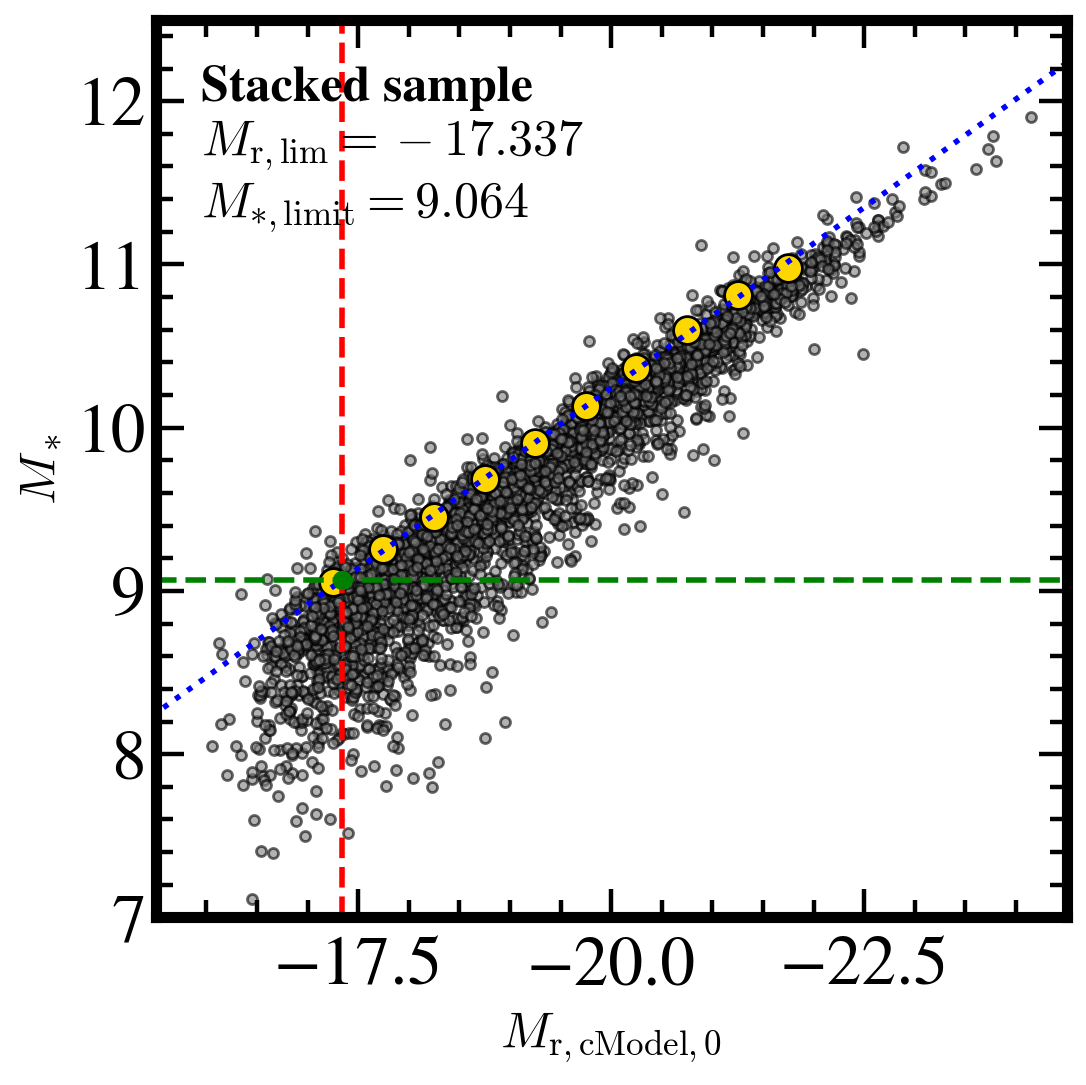

In [3]:
from scipy.stats import linregress

# ---------------------------------------------------------
# 1. Build stacked sample (no CLID separation)
# ---------------------------------------------------------
# Use all galaxies with valid redshift
df_stack = df_mach_members.loc[df_mach_members["Z_TOT_Z"] != -99].copy()

# ---------------------------------------------------------
# 2. Set up single-panel figure
# ---------------------------------------------------------
fig, ax = plt.subplots(figsize=(6, 6))

# Scatter plot of all individual galaxies
ax.scatter(
    df_stack["AbsMag_r"],
    df_stack["M_MASS_CIGALE_PARK"],
    c="gray",
    edgecolor="black",
    s=13,
    alpha=0.6,
    label="Data points",
)

# Axis limits and orientation
ax.set_xlim(-24.5, -15.5)
ax.invert_xaxis()
ax.set_ylim(7, 12.5)

# ---------------------------------------------------------
# 3. Binning and 90% (yellow) points in -22 <= M_r <= -17
# ---------------------------------------------------------
bin_width = 0.5
mr_min, mr_max = -22.0, -17.0  # range used to define yellow circles

bin_edges = np.arange(mr_min, mr_max + bin_width, bin_width)
bins = pd.cut(df_stack["AbsMag_r"], bins=bin_edges, include_lowest=True)

bin_centers = []
percentile_90 = []

for b in bins.unique():
    if pd.isna(b):
        continue

    bin_data = df_stack[bins == b]
    if len(bin_data) == 0:
        continue

    center = b.mid
    limit_90 = np.percentile(bin_data["M_MASS_CIGALE_PARK"], 90)

    bin_centers.append(center)
    percentile_90.append(limit_90)

    # Yellow circles: only in the chosen M_r range by construction
    ax.plot(
        center,
        limit_90,
        "o",
        markersize=10,
        color="gold",
        markeredgecolor="black",
        label="90th Percentile" if len(bin_centers) == 1 else "",
    )

bin_centers = np.array(bin_centers)
percentile_90 = np.array(percentile_90)

# ---------------------------------------------------------
# 4. Red vertical line fixed at M_r = -17.337
# ---------------------------------------------------------
abs_mag_threshold = -17.337  # fixed red dashed line position

ax.axvline(
    abs_mag_threshold,
    color="red",
    linestyle="--",
    linewidth=2,
    label=r"Fixed limit $M_r = -17.337$",
)

# ---------------------------------------------------------
# 5. Linear regression on yellow points left of the red line
#    (still using only the yellow circles from -22 <= M_r <= -17)
# ---------------------------------------------------------
left_mask = bin_centers < abs_mag_threshold

if np.any(left_mask) and np.sum(left_mask) >= 2:
    left_centers = bin_centers[left_mask]
    left_percentiles = percentile_90[left_mask]

    # Linear regression on selected yellow circles
    slope, intercept, _, _, _ = linregress(left_centers, left_percentiles)

    # Blue regression line drawn across the full x-range
    regression_x = np.linspace(-24.5, -15.5, 200)
    regression_y = intercept + slope * regression_x
    ax.plot(
        regression_x,
        regression_y,
        color="blue",
        linestyle=":",
        linewidth=2,
        label="Linear Regression",
    )

    # Green horizontal line at intersection with red vertical line
    intersection_y = intercept + slope * abs_mag_threshold
    ax.axhline(
        intersection_y,
        color="green",
        linestyle="--",
        linewidth=2,
        label="Intersection Limit",
    )
    ax.plot(
        abs_mag_threshold,
        intersection_y,
        "go",
        markersize=6,
        label="Intersection Point",
    )

    # Print intersection values
    print("STACKED sample intersection:")
    print(f"  M_r (red vertical)          = {abs_mag_threshold:.3f}")
    print(f"  M_limit (green horizontal)  = {intersection_y:.3f}")

    # Annotation text
    annotation_text = (
        "Stacked sample\n"
        rf"$M_{{\mathrm{{r,lim}}}} = {abs_mag_threshold:.3f}$" "\n"
        rf"$M_{{\mathrm{{*,limit}}}} = {intersection_y:.3f}$"
    )
else:
    intersection_y = None
    print("Not enough 90th-percentile points left of the red line for regression.")
    annotation_text = "MACH Stacked sample\n(no intersection)"

ax.annotate(
    annotation_text,
    xy=(0.05, 0.95),
    xycoords="axes fraction",
    fontsize=18,
    fontweight="bold",
    color="black",
    va="top",
)

# ---------------------------------------------------------
# 6. Labels, ticks, and style
# ---------------------------------------------------------
ax.set_xlabel(r"$M_{\mathrm{r,cModel,0}}$", fontsize=18)
ax.set_ylabel(r"$M_*$", fontsize=18)

ax.xaxis.set_tick_params(which="both", direction="in", top=True, bottom=True)
ax.yaxis.set_tick_params(which="both", direction="in", right=True, left=True)
ax.minorticks_on()

# Optional: show legend
# ax.legend(fontsize=10, loc="lower left")

plt.tight_layout()
plt.show()

Intersection point for CLID A2245: (-17.30, 8.99)
Intersection point for CLID A1767: (-16.85, 8.77)
Intersection point for CLID A2244: (-17.84, 9.29)
Intersection point for CLID A1831: (-17.73, 9.23)
Intersection point for CLID A2034: (-18.13, 9.44)
Intersection point for CLID A7: (-17.92, 9.33)
Intersection point for CLID A2255: (-17.40, 9.09)
Intersection point for CLID A2029: (-17.37, 9.14)
Intersection point for CLID A2065: (-16.99, 8.85)


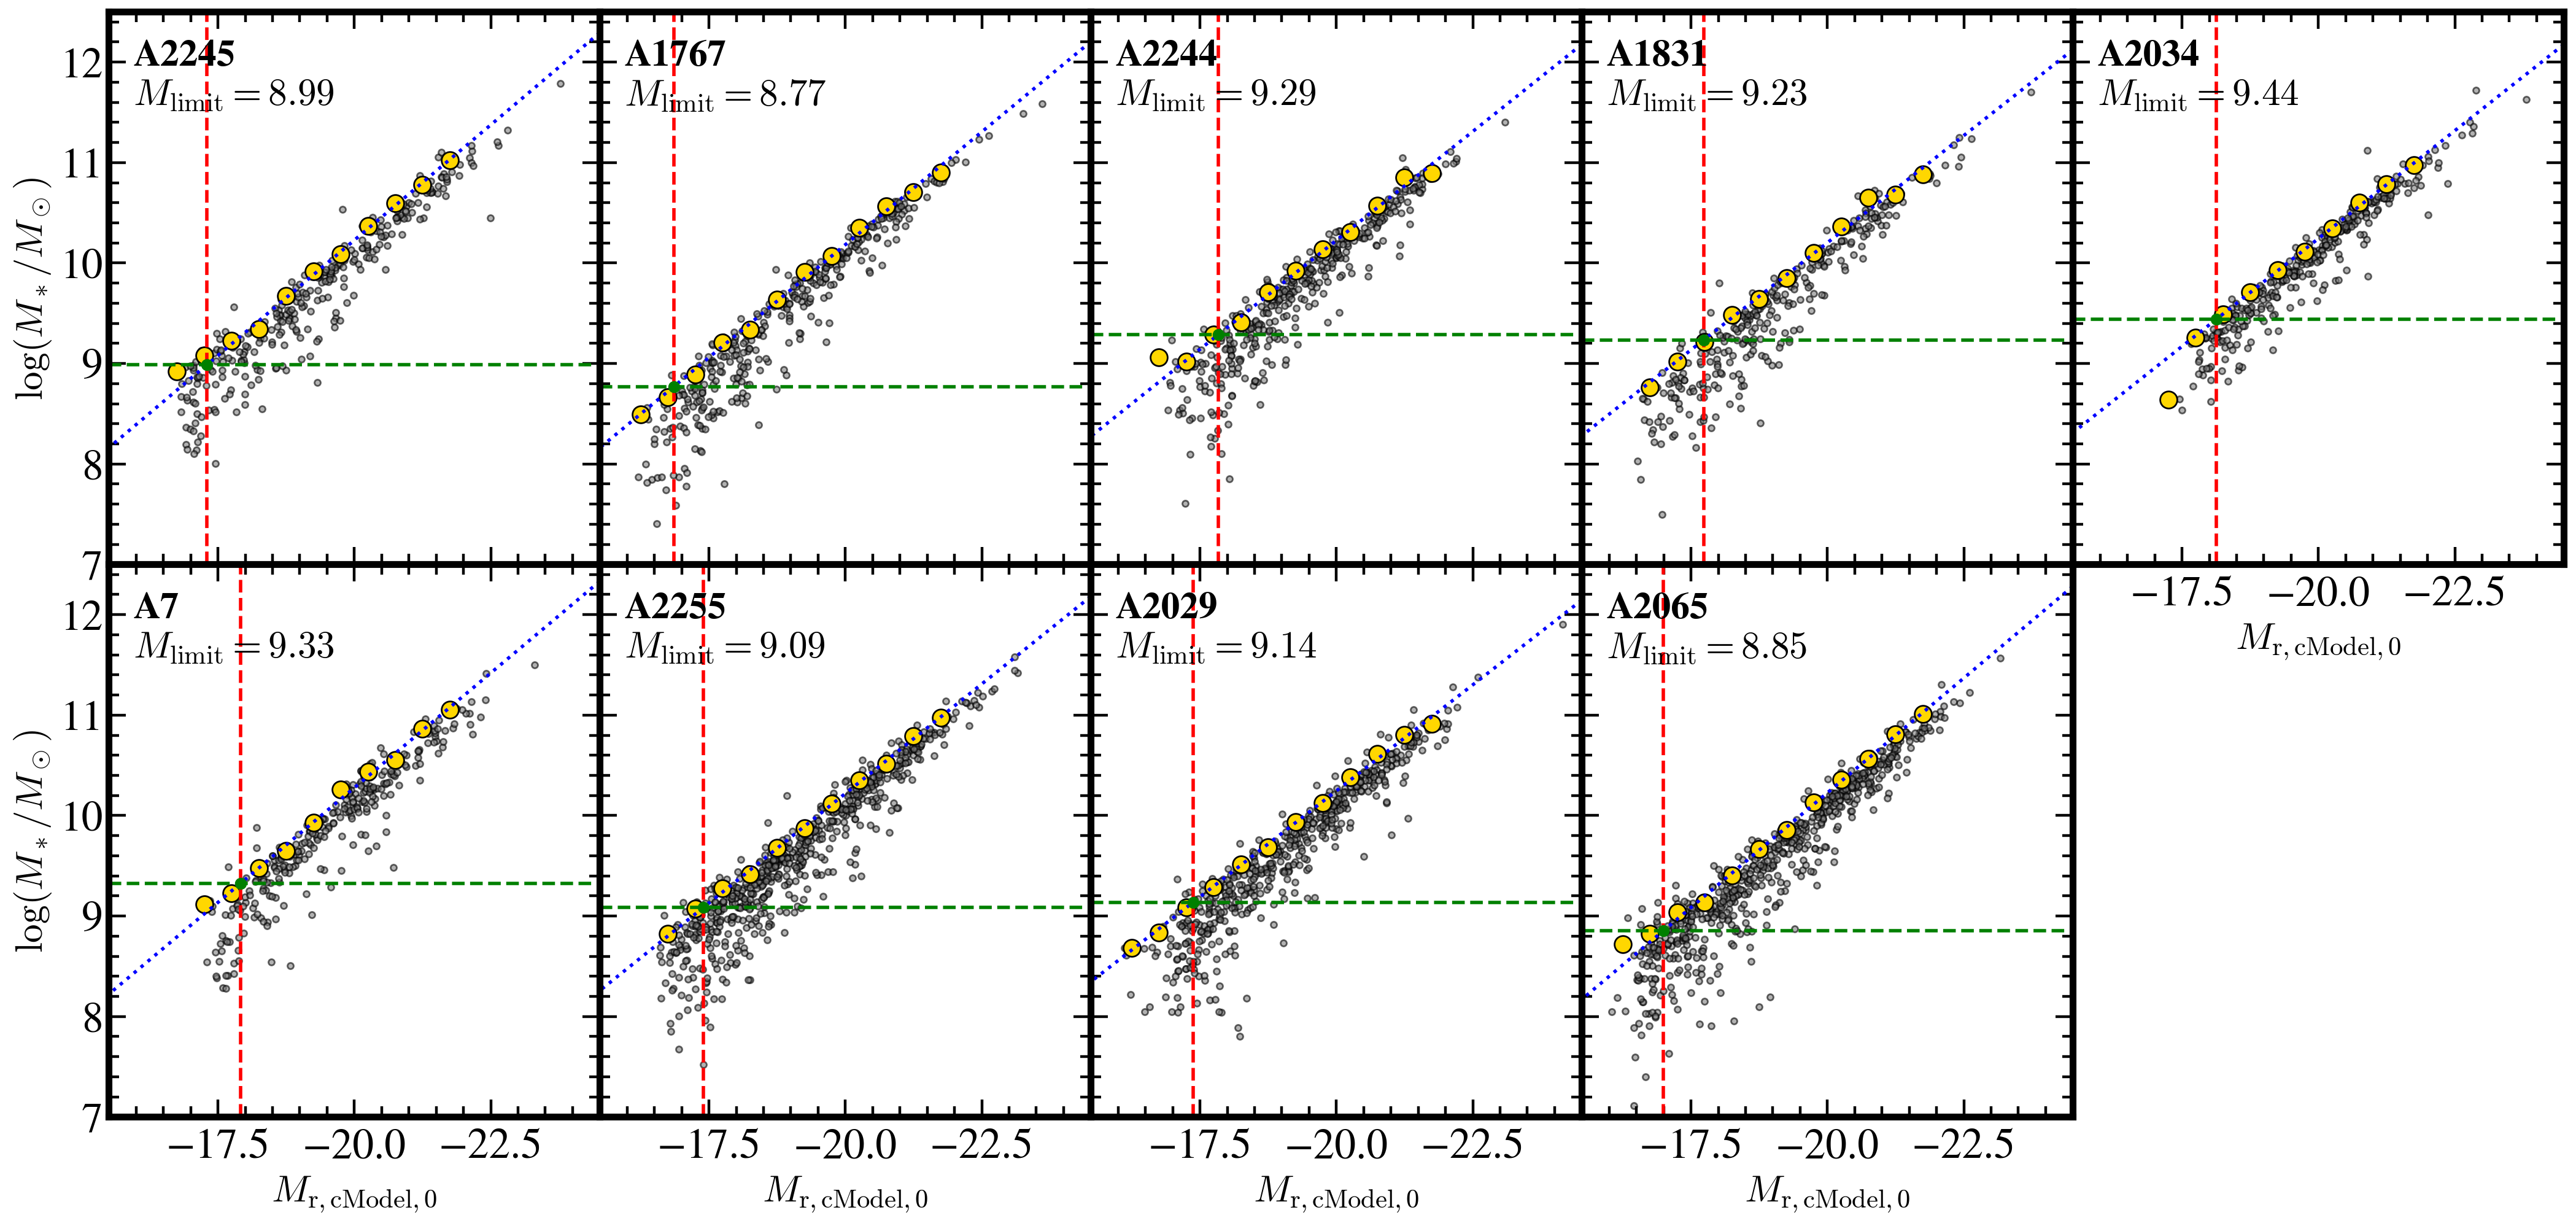

In [4]:
from scipy.stats import linregress

# ---------------------------------------------------------
# 1. Prepare multi-panel figure
# ---------------------------------------------------------
unique_clids = MACHLIST
n_subplots = len(unique_clids)
n_cols = 5
n_rows = (n_subplots + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 9))

# Remove gaps between panels
plt.subplots_adjust(left=0, right=1, top=1, bottom=0, wspace=0, hspace=0)

# List to collect per-cluster M_limit values
limit_list = []

# ---------------------------------------------------------
# 2. Loop over clusters
# ---------------------------------------------------------
for i, clid in enumerate(unique_clids):
    ax = axes.flat[i]

    # Use members with valid redshift for this cluster
    df_clid = df_mach_members[
        (df_mach_members["CLID"] == clid) & (df_mach_members["Z_TOT_Z"] != -99)
    ].copy()

    # Skip empty clusters safely
    if df_clid.empty:
        ax.set_axis_off()
        continue

    # Spectroscopic completeness (exceed_bin) value for this cluster
    exceed_bin_value = exceed_bin_df.loc[
        exceed_bin_df["TARGET"] == clid, "exceed_bin"
    ].values[0]

    # Scatter plot of all galaxies in the cluster
    ax.scatter(
        df_clid["AbsMag_r"],
        df_clid["M_MASS_CIGALE_PARK"],
        c="gray",
        edgecolor="black",
        s=13,
        alpha=0.6,
        label="Data points",
    )

    # Axis limits and orientation
    ax.set_xlim(-24.5, -15.5)
    ax.invert_xaxis()
    ax.set_ylim(7, 12.5)

    # -----------------------------------------------------
    # 3. Binning and 90% (yellow) points in -22 <= M_r <= -17
    # -----------------------------------------------------
    bin_width = 0.5
    mr_min, mr_max = -22.0, -16.0

    bin_edges = np.arange(mr_min, mr_max + bin_width, bin_width)
    bins = pd.cut(df_clid["AbsMag_r"], bins=bin_edges, include_lowest=True)

    bin_centers = []
    percentile_90 = []

    for b in bins.unique():
        if pd.isna(b):
            continue
        bin_data = df_clid[bins == b]
        if len(bin_data) == 0:
            continue

        center = b.mid
        limit_90 = np.percentile(bin_data["M_MASS_CIGALE_PARK"], 90)

        bin_centers.append(center)
        percentile_90.append(limit_90)

        # Yellow 90th-percentile circle
        ax.plot(
            center,
            limit_90,
            "o",
            markersize=10,
            color="gold",
            markeredgecolor="black",
            label="90th Percentile" if len(bin_centers) == 1 else "",
        )

    bin_centers = np.array(bin_centers)
    percentile_90 = np.array(percentile_90)

    # -----------------------------------------------------
    # 4. Red vertical line from exceed_bin value
    # -----------------------------------------------------
    lum_distances = cosmo.luminosity_distance(df_clid["Z_TOT_Z"]).to("pc").value
    abs_mag_limit = exceed_bin_value - 5 * np.log10(lum_distances / 10)
    abs_mag_threshold = np.min(abs_mag_limit)  # brightest (smallest) M_r allowed

    ax.axvline(
        abs_mag_threshold,
        color="red",
        linestyle="--",
        linewidth=2,
        label=f"Exceed limit {exceed_bin_value}",
    )

    # -----------------------------------------------------
    # 5. Fit blue line to yellow points left of red line
    # -----------------------------------------------------
    intersection_y = None

    if bin_centers.size > 0:
        left_mask = bin_centers < abs_mag_threshold  # brighter than red line

        if np.sum(left_mask) >= 2:
            fit_x = bin_centers[left_mask]
            fit_y = percentile_90[left_mask]

            # Linear regression on selected yellow circles
            slope, intercept, _, _, _ = linregress(fit_x, fit_y)

            # Blue regression line across full x-range
            regression_x = np.linspace(-24.5, -15.5, 200)
            regression_y = intercept + slope * regression_x
            ax.plot(
                regression_x,
                regression_y,
                color="blue",
                linestyle=":",
                linewidth=2,
                label="Linear Regression",
            )

            # Green horizontal line at intersection with red vertical line
            intersection_y = intercept + slope * abs_mag_threshold
            ax.axhline(
                intersection_y,
                color="green",
                linestyle="--",
                linewidth=2,
                label="Intersection Limit",
            )
            ax.plot(
                abs_mag_threshold,
                intersection_y,
                "go",
                markersize=6,
                label="Intersection Point",
            )

            print(
                f"Intersection point for CLID {clid}: "
                f"({abs_mag_threshold:.2f}, {intersection_y:.2f})"
            )

            # Save M_limit for this cluster
            limit_list.append({"CLID": clid, "Mlimit": intersection_y})

    # -----------------------------------------------------
    # 6. Labels, ticks, and annotation
    # -----------------------------------------------------
    if i % n_cols == 0:
        ax.set_ylabel(r"$\log(M_*/M_\odot)$", fontsize=22)
    else:
        ax.set_yticklabels([])

    if i >= (n_rows - 1) * n_cols - 1:
        ax.set_xlabel(r"$M_{\mathrm{r,cModel,0}}$", fontsize=22)
    else:
        ax.set_xticklabels([])

    # Per-panel text: cluster name and M_limit (if available)
    annotation_text = f"{clid}"
    if intersection_y is not None:
        annotation_text += f"\n$M_{{\\mathrm{{limit}}}}={intersection_y:.2f}$"

    ax.annotate(
        annotation_text,
        xy=(0.05, 0.95),
        xycoords="axes fraction",
        fontsize=22,
        fontweight="bold",
        color="black",
        va="top",
    )

    ax.xaxis.set_tick_params(which="both", direction="in", top=True, bottom=True)
    ax.yaxis.set_tick_params(which="both", direction="in", right=True, left=True)
    ax.minorticks_on()

# ---------------------------------------------------------
# 7. Hide unused panels and show
# ---------------------------------------------------------
for j in range(i + 1, n_rows * n_cols):
    fig.delaxes(axes.flat[j])

plt.show()

# Optional: save the per-cluster M_limit table
# pd.DataFrame(limit_list).to_csv("rawSMF_mass_limit_per_cluster.csv", index=False)